In [1]:
%matplotlib inline

In [1]:
from pathlib import Path

for p in Path("../data/bookshelf_yolo").iterdir():
    print(p)

..\data\bookshelf_yolo\data.yaml
..\data\bookshelf_yolo\test
..\data\bookshelf_yolo\train
..\data\bookshelf_yolo\valid


In [2]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [3]:
results = model.train(
    data="../data/bookshelf_yolo/data.yaml",
    epochs=50,
    imgsz=640,
    batch=32,
    workers=4,
    device=0
)

New https://pypi.org/project/ultralytics/8.4.63 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.62  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/bookshelf_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, m

In [5]:
from ultralytics import YOLO

model = YOLO("../runs/detect/train/weights/best.pt")

metrics = model.val()

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.62  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 165.666.4 MB/s, size: 50.7 KB)
val: Scanning C:\Users\anshu\Documents\codes\ML\BookRecomendation\data\bookshelf_yolo\valid\labels.cache... 1323 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1323/1323  0.0s
val: C:\Users\anshu\Documents\codes\ML\BookRecomendation\data\bookshelf_yolo\valid\images\20240221_103329_jpg.rf.55e749bc6ff93f4ec5b83098d89c4a56.jpg: 1 duplicate labels removed
WARNING Box and segment counts should be equal, but got len(segments) = 22152, len(boxes) = 22359. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━


image 1/1 c:\Users\anshu\Documents\codes\ML\BookRecomendation\notebooks\..\data\cv\images\20.jpeg: 640x480 165 books, 65.9ms
Speed: 2.4ms preprocess, 65.9ms inference, 18.4ms postprocess per image at shape (1, 3, 640, 480)


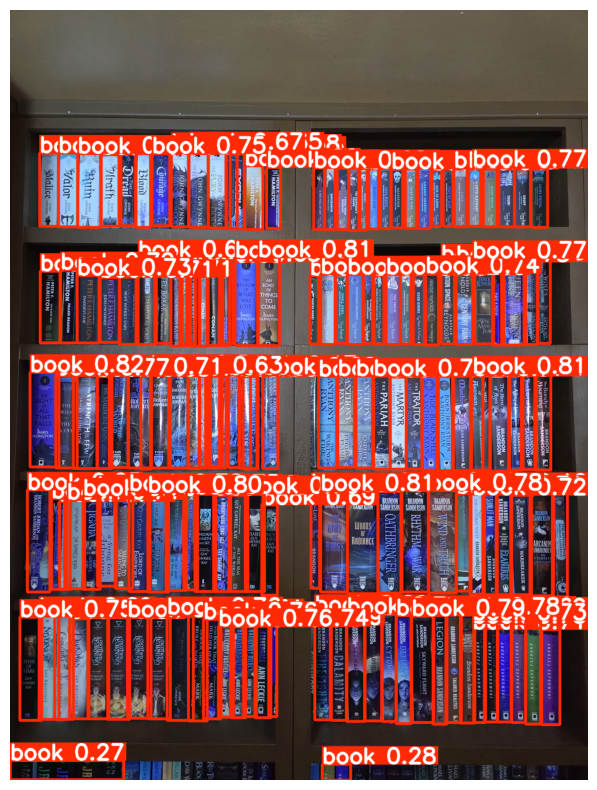

Detected books: 165


In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("../runs/detect/train/weights/best.pt")

results = model("../data/cv/images/20.jpeg")

img = results[0].plot()

plt.figure(figsize=(15,10))
plt.imshow(img)
plt.axis("off")
plt.show()

print("Detected books:", len(results[0].boxes))


image 1/1 c:\Users\anshu\Documents\codes\ML\BookRecomendation\notebooks\..\data\cv\images\10.jpeg: 640x320 63 books, 46.5ms
Speed: 1.3ms preprocess, 46.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 320)


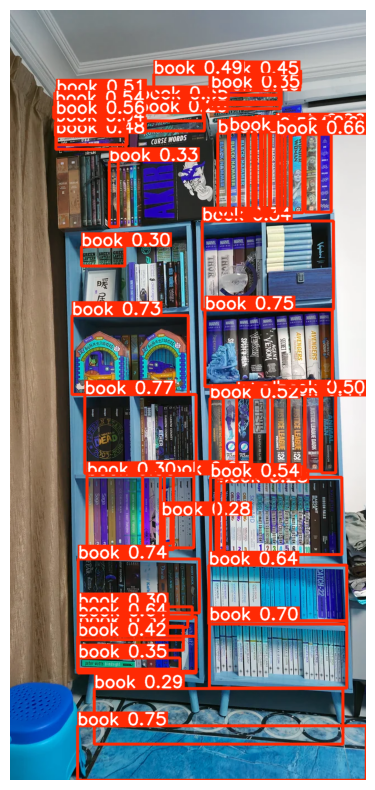

In [3]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("../runs/detect/train/weights/best.pt")

results = model("../data/cv/images/10.jpeg")

img = results[0].plot()

plt.figure(figsize=(20,10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [4]:
from pathlib import Path

Path("../outputs/book_spines").mkdir(
    parents=True,
    exist_ok=True
)

In [5]:
import cv2
from ultralytics import YOLO

model = YOLO("../runs/detect/train/weights/best.pt")

img_path = "../data/cv/images/20.jpeg"

results = model(img_path)

img = cv2.imread(img_path)

for i, box in enumerate(results[0].boxes.xyxy.cpu().numpy()):
    x1, y1, x2, y2 = map(int, box)

    crop = img[y1:y2, x1:x2]

    cv2.imwrite(
        f"../outputs/book_spines/spine_{i}.jpg",
        crop
    )

print("Saved:", len(results[0].boxes), "spines")


image 1/1 c:\Users\anshu\Documents\codes\ML\BookRecomendation\notebooks\..\data\cv\images\20.jpeg: 640x480 165 books, 11.4ms
Speed: 1.9ms preprocess, 11.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
Saved: 165 spines


In [6]:
import easyocr

reader = easyocr.Reader(['en'])

result = reader.readtext(
    "../outputs/book_spines/spine_0.jpg"
)

print(result)

ValueError: too many values to unpack (expected 2)

In [7]:
import cv2

img = cv2.imread("../outputs/book_spines/spine_0.jpg")

print(type(img))
print(img.shape)

<class 'numpy.ndarray'>
(177, 54, 3)


In [8]:
import cv2
import easyocr

img = cv2.imread("../outputs/book_spines/spine_0.jpg")

reader = easyocr.Reader(['en'])

result = reader.readtext(img)

print(result)

[([[np.int32(9), np.int32(41)], [np.int32(45), np.int32(41)], [np.int32(45), np.int32(61)], [np.int32(9), np.int32(61)]], 'GHT', np.float64(0.3412597542259835)), ([[np.int32(13), np.int32(79)], [np.int32(43), np.int32(79)], [np.int32(43), np.int32(91)], [np.int32(13), np.int32(91)]], 'AT', np.float64(0.32778982454215383)), ([[np.int32(9), np.int32(89)], [np.int32(43), np.int32(89)], [np.int32(43), np.int32(103)], [np.int32(9), np.int32(103)]], 'FALLS', np.float64(0.2507998025087985)), ([[np.int32(4), np.int32(114)], [np.int32(44), np.int32(114)], [np.int32(44), np.int32(122)], [np.int32(4), np.int32(122)]], 'MITTON', np.float64(0.009170009834276807))]


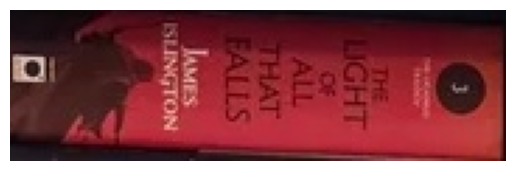

In [9]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("../outputs/book_spines/spine_0.jpg")

rot = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

plt.imshow(cv2.cvtColor(rot, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [10]:
result = reader.readtext(rot)
print(result)

[([[np.int32(72), np.int32(14)], [np.int32(140), np.int32(14)], [np.int32(140), np.int32(44)], [np.int32(72), np.int32(44)]], 'E4ere?', np.float64(0.09529302463705966))]


In [11]:
import cv2

img = cv2.imread("../outputs/book_spines/spine_0.jpg")

rot = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

big = cv2.resize(
    rot,
    None,
    fx=4,
    fy=4,
    interpolation=cv2.INTER_CUBIC
)

result = reader.readtext(big)

print(result)

[([[np.int32(199), np.int32(3)], [np.int32(531), np.int32(3)], [np.int32(531), np.int32(189)], [np.int32(199), np.int32(189)]], 'pe4eaq', np.float64(0.1144417175467303)), ([[np.int32(509), np.int32(79)], [np.int32(547), np.int32(79)], [np.int32(547), np.int32(133)], [np.int32(509), np.int32(133)]], '3', np.float64(0.1561037254432449))]


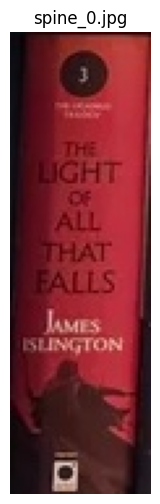

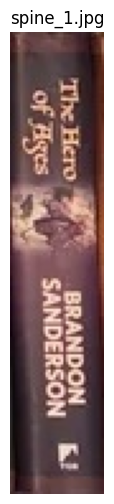

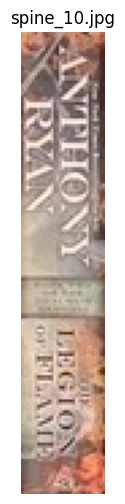

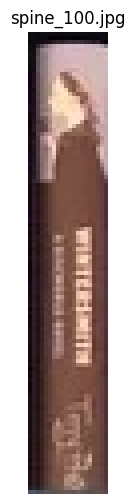

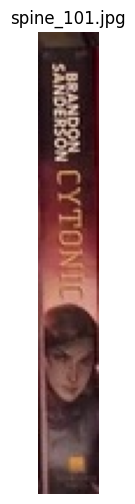

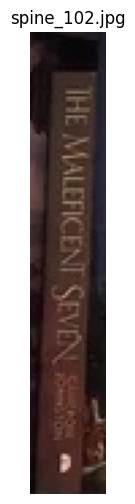

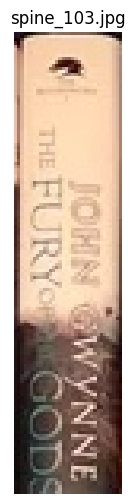

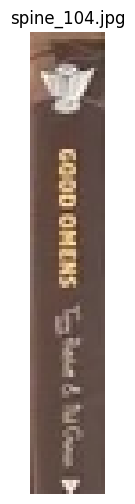

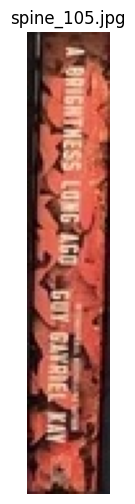

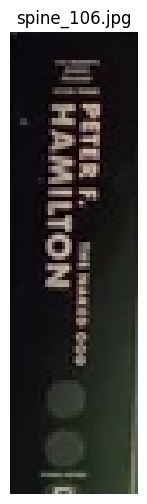

In [12]:
import os
import cv2
import matplotlib.pyplot as plt

files = sorted(os.listdir("../outputs/book_spines"))[:10]

for f in files:
    img = cv2.imread(f"../outputs/book_spines/{f}")

    plt.figure(figsize=(2,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f)
    plt.axis("off")
    plt.show()

In [13]:
import cv2
import easyocr

reader = easyocr.Reader(['en'])

img = cv2.imread("../outputs/book_spines/spine_0.jpg")

rot = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

result = reader.readtext(rot)

for r in result:
    print(r[1])

E4ere?


In [14]:
import cv2

rot = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

big = cv2.resize(
    rot,
    None,
    fx=4,
    fy=4,
    interpolation=cv2.INTER_CUBIC
)

result = reader.readtext(big)

for r in result:
    print(r[1])

pe4eaq
3


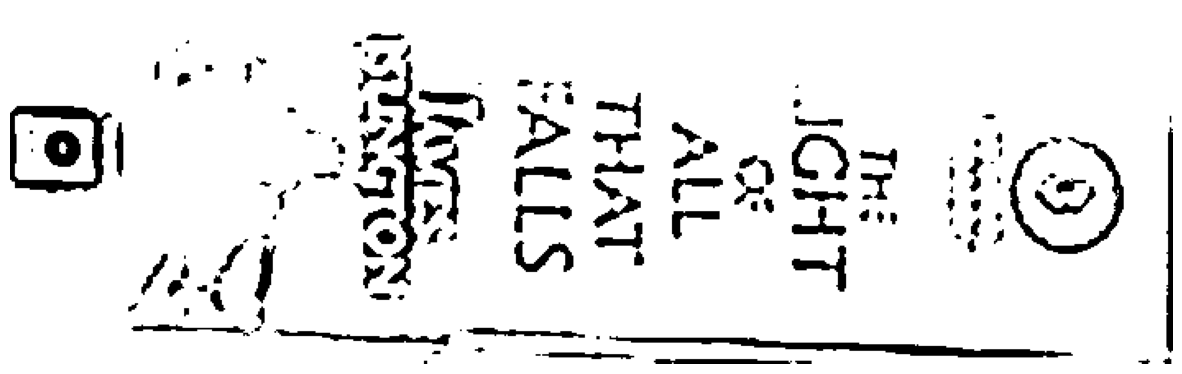

Exee
2


In [15]:
import cv2
import matplotlib.pyplot as plt
import easyocr

reader = easyocr.Reader(['en'])

img = cv2.imread("../outputs/book_spines/spine_0.jpg")

# Rotate horizontal
img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

# Upscale 4x
img = cv2.resize(
    img,
    None,
    fx=4,
    fy=4,
    interpolation=cv2.INTER_CUBIC
)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Adaptive threshold
gray = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31,
    11
)

plt.figure(figsize=(15,5))
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

result = reader.readtext(gray)

for r in result:
    print(r[1])

In [16]:
img = cv2.imread("../outputs/book_spines/spine_0.jpg")

rot = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

big = cv2.resize(
    rot,
    None,
    fx=4,
    fy=4,
    interpolation=cv2.INTER_CUBIC
)

result = reader.readtext(big)

for r in result:
    print(r[1], r[2])

pe4eaq 0.1144417175467303
3 0.1561037254432449


In [17]:
result = reader.readtext(
    big,
    paragraph=True
)

print(result)

[[[[199, 3], [547, 3], [547, 189], [199, 189]], 'pe4eaq 3']]


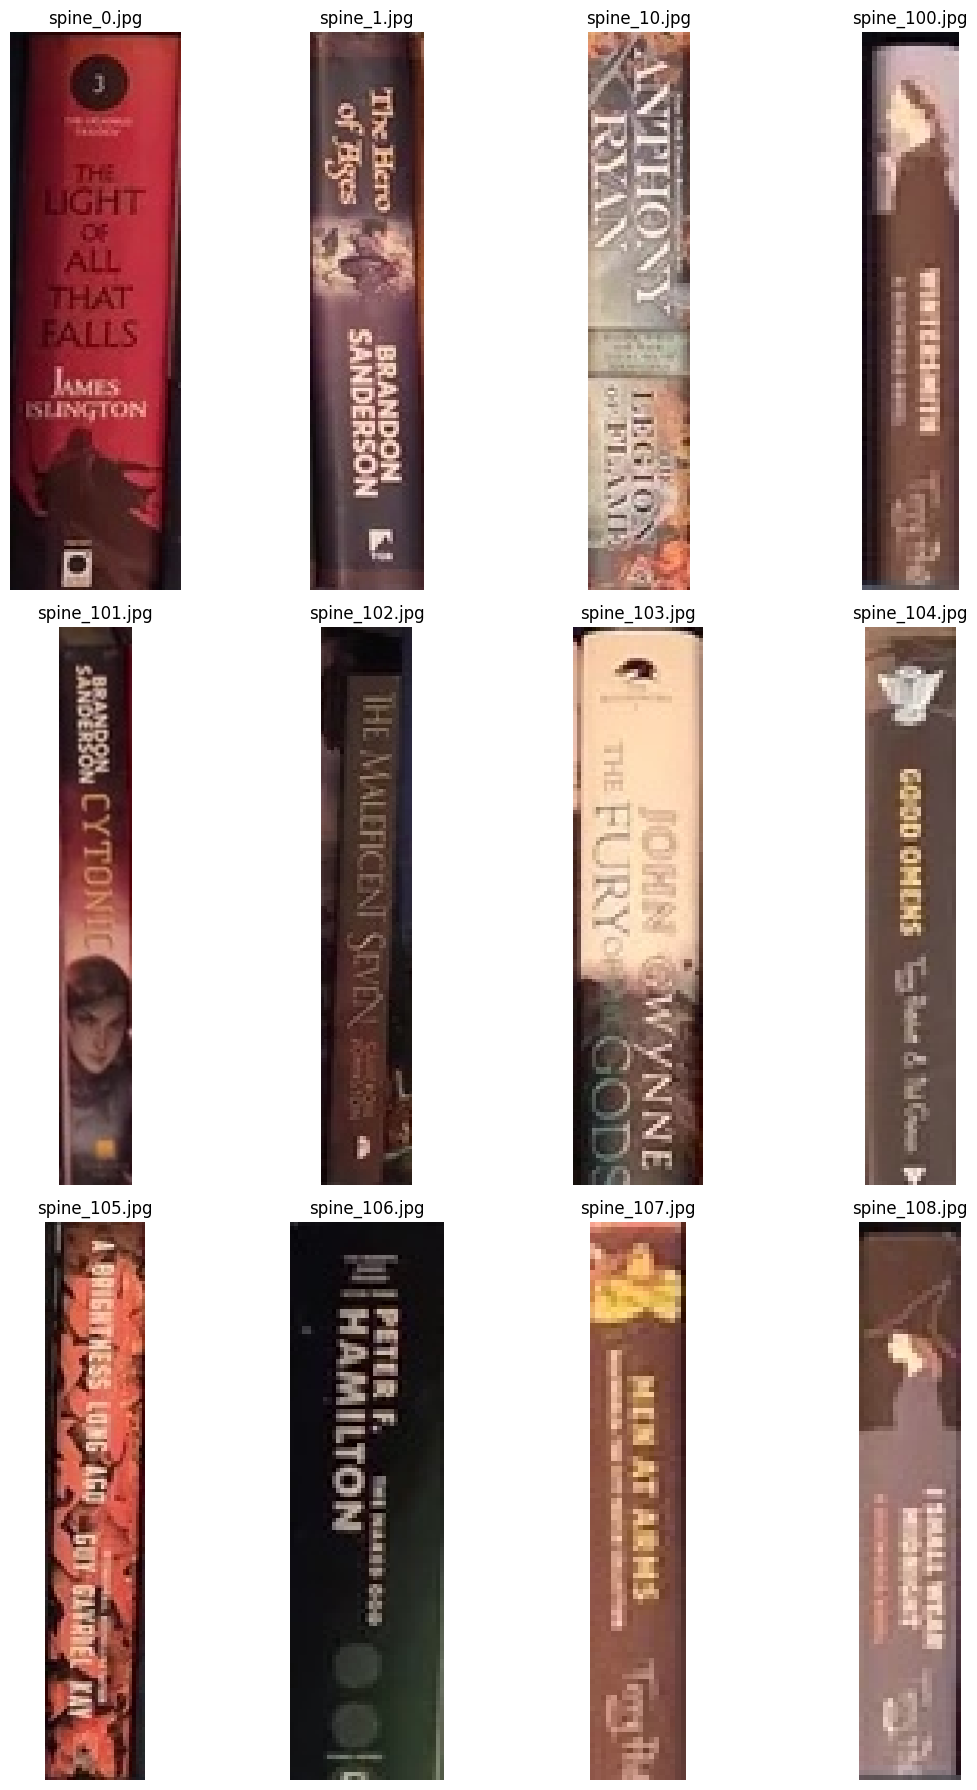

In [18]:
import os
import cv2
import matplotlib.pyplot as plt

files = sorted(os.listdir("../outputs/book_spines"))[:12]

fig, axes = plt.subplots(3, 4, figsize=(12, 18))

for ax, f in zip(axes.ravel(), files):
    img = cv2.imread(f"../outputs/book_spines/{f}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(f)
    ax.axis("off")

plt.tight_layout()
plt.show()

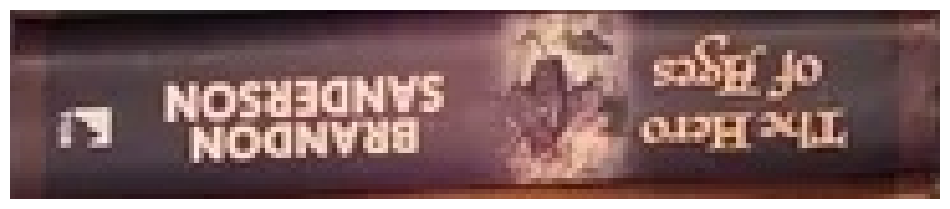

In [19]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("../outputs/book_spines/spine_1.jpg")

rot = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

plt.figure(figsize=(12,4))
plt.imshow(cv2.cvtColor(rot, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [20]:
import cv2
import easyocr

reader = easyocr.Reader(['en'])

img = cv2.imread("../outputs/book_spines/spine_1.jpg")

candidates = [
    img,
    cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE),
    cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE),
    cv2.rotate(img, cv2.ROTATE_180),
]

best_text = ""
best_score = 0

for i, im in enumerate(candidates):
    result = reader.readtext(im)

    if len(result):
        score = sum(r[2] for r in result) / len(result)
        text = " ".join(r[1] for r in result)

        print(f"Rotation {i}:")
        print(text)
        print("score:", score)

        if score > best_score:
            best_score = score
            best_text = text

print("\nBEST:")
print(best_text)
print(best_score)

Rotation 0:
3 0
score: 0.25719128670314406
Rotation 1:
SSp Jo NoSaronvs QUZHGu
score: 0.13841907252921043
Rotation 2:
Ircrcro SARDERCON of Hses
score: 0.36774955832543843
Rotation 3:
1 E}
score: 0.2249867628524398

BEST:
Ircrcro SARDERCON of Hses
0.36774955832543843


In [2]:
import cv2
import easyocr
import numpy as np

reader = easyocr.Reader(['en'])

def best_ocr(img_path):
    img = cv2.imread(img_path)

    rotations = {
        "original": img,
        "90_cw": cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE),
        "90_ccw": cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE),
        "180": cv2.rotate(img, cv2.ROTATE_180),
    }

    best_rotation = None
    best_text = ""
    best_score = -1

    for name, im in rotations.items():

        # upscale
        h, w = im.shape[:2]
        im_big = cv2.resize(
            im,
            (w * 4, h * 4),
            interpolation=cv2.INTER_CUBIC
        )

        result = reader.readtext(im_big)

        if len(result) == 0:
            print(f"\n{name}")
            print("No text detected")
            continue

        text = " ".join([r[1] for r in result])
        score = np.mean([r[2] for r in result])

        print("\n" + "=" * 50)
        print(f"Rotation: {name}")
        print(f"Score: {score:.3f}")
        print(text)

        if score > best_score:
            best_score = score
            best_text = text
            best_rotation = name

    print("\n" + "=" * 50)
    print("BEST RESULT")
    print(f"Rotation: {best_rotation}")
    print(f"Score: {best_score:.3f}")
    print(best_text)

    return {
        "rotation": best_rotation,
        "score": best_score,
        "text": best_text
    }

In [3]:
result = best_ocr(
    "../outputs/book_spines/spine_1.jpg"
)

print(result)


Rotation: original
Score: 0.306
3 p

Rotation: 90_cw
Score: 0.370
NOSUJONVS  SS Jo NoaNV8B OPHML

Rotation: 90_ccw
Score: 0.672
Tk Hero BRANDON of Bses SANDERSON

Rotation: 180
Score: 0.227
0 I8

BEST RESULT
Rotation: 90_ccw
Score: 0.672
Tk Hero BRANDON of Bses SANDERSON
{'rotation': '90_ccw', 'score': np.float64(0.6720427428409745), 'text': 'Tk Hero BRANDON of Bses SANDERSON'}


In [9]:
import re

def clean_ocr(text):
    words = []

    for w in text.split():

        w = re.sub(r"[^A-Za-z]", "", w)

        if len(w) < 3:
            continue

        words.append(w.lower())

    return words

In [10]:
ocr_text = "Tk Hero BRANDON of Bses SANDERSON"

words = clean_ocr(ocr_text)

print(words)

['hero', 'brandon', 'bses', 'sanderson']


In [11]:
query = " ".join(words)

print(query)

hero brandon bses sanderson


In [12]:
import pandas as pd

google = pd.read_csv(
    "../data/raw/google_books_dataset.csv",
    low_memory=False
)

print(google.shape)

(15147, 21)


In [13]:
google["search_text"] = (
    google["title"].fillna("") + " " +
    google["authors"].fillna("")
)

print(google["search_text"].head())

0                   Bestsellers Ivan King, bestsellers
1                   Bestsellers Ivan King, bestsellers
2    The Bestseller Code Jodie Archer, Matthew L. J...
3                          Bestseller Robert McParland
4     Bestsellers: Popular Fiction since 1900 C. Bloom
Name: search_text, dtype: str


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = google["search_text"].tolist()

vectorizer = TfidfVectorizer(
    stop_words="english"
)

X = vectorizer.fit_transform(corpus)

print(X.shape)

(15147, 20442)


In [15]:
from sklearn.metrics.pairwise import cosine_similarity

query = "hero brandon sanderson"

q = vectorizer.transform([query])

sims = cosine_similarity(q, X)[0]

idx = sims.argsort()[-10:][::-1]

google.iloc[idx][["title", "authors"]]

,title,authors
14690,The Hero of Ages,Brandon Sanderson
14678,The Hero of Ages,Brandon Sanderson
14700,Mistborn,Brandon Sanderson
14712,Mistborn,Brandon Sanderson
14722,Alcatraz,Brandon Sanderson
14672,Defiant,Brandon Sanderson
14687,Calamity,Brandon Sanderson
14680,Elantris,Brandon Sanderson
14679,Elantris,Brandon Sanderson
14706,Defiant,Brandon Sanderson


In [1]:
import pandas as pd

google = pd.read_csv(
    "../data/raw/google_books_dataset.csv",
    low_memory=False
)

print(google.shape)

(15147, 21)


In [2]:
google["search_text"] = (
    google["title"].fillna("") + " " +
    google["authors"].fillna("")
)

google["search_text"].head()

0                   Bestsellers Ivan King, bestsellers
1                   Bestsellers Ivan King, bestsellers
2    The Bestseller Code Jodie Archer, Matthew L. J...
3                          Bestseller Robert McParland
4     Bestsellers: Popular Fiction since 1900 C. Bloom
Name: search_text, dtype: str

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = google["search_text"].tolist()

vectorizer = TfidfVectorizer(
    stop_words="english"
)

X = vectorizer.fit_transform(corpus)

print(X.shape)

(15147, 20442)


In [4]:
import re

def clean_ocr(text):

    words = []

    for w in text.split():

        w = re.sub(r"[^A-Za-z]", "", w)

        if len(w) < 3:
            continue

        words.append(w.lower())

    return " ".join(words)

In [5]:
ocr_text = "Tk Hero BRANDON of Bses SANDERSON"

print(clean_ocr(ocr_text))

hero brandon bses sanderson


In [6]:
from sklearn.metrics.pairwise import cosine_similarity

def retrieve_book(query, top_k=5):

    q = vectorizer.transform([query])

    sims = cosine_similarity(q, X)[0]

    idx = sims.argsort()[-top_k:][::-1]

    results = google.iloc[idx][
        ["title", "authors"]
    ].copy()

    results["score"] = sims[idx]

    return results

In [7]:
retrieve_book(
    "hero brandon sanderson"
)

,title,authors,score
14690,The Hero of Ages,Brandon Sanderson,0.84218
14678,The Hero of Ages,Brandon Sanderson,0.84218
14700,Mistborn,Brandon Sanderson,0.51219
14712,Mistborn,Brandon Sanderson,0.51219
14722,Alcatraz,Brandon Sanderson,0.50598


In [8]:
import cv2
import easyocr
import numpy as np

reader = easyocr.Reader(['en'])

def best_ocr(img_path):

    img = cv2.imread(img_path)

    rotations = {
        "original": img,
        "90_cw": cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE),
        "90_ccw": cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE),
        "180": cv2.rotate(img, cv2.ROTATE_180),
    }

    best_text = ""
    best_score = -1

    for name, im in rotations.items():

        h, w = im.shape[:2]

        im = cv2.resize(
            im,
            (w * 4, h * 4),
            interpolation=cv2.INTER_CUBIC
        )

        result = reader.readtext(im)

        if len(result) == 0:
            continue

        text = " ".join(
            r[1] for r in result
        )

        score = np.mean(
            [r[2] for r in result]
        )

        if score > best_score:
            best_score = score
            best_text = text

    return best_text

In [9]:
def identify_book_from_spine(img_path):

    ocr_text = best_ocr(img_path)

    query = clean_ocr(ocr_text)

    results = retrieve_book(
        query,
        top_k=5
    )

    return {
        "ocr": ocr_text,
        "query": query,
        "matches": results
    }

In [10]:
result = identify_book_from_spine(
    "../outputs/book_spines/spine_1.jpg"
)

print("OCR:")
print(result["ocr"])

print("\nQuery:")
print(result["query"])

print("\nMatches:")
print(result["matches"])

OCR:
Tk Hero BRANDON of Bses SANDERSON

Query:
hero brandon bses sanderson

Matches:
                  title            authors    score
14690  The Hero of Ages  Brandon Sanderson  0.84218
14678  The Hero of Ages  Brandon Sanderson  0.84218
14700          Mistborn  Brandon Sanderson  0.51219
14712          Mistborn  Brandon Sanderson  0.51219
14722          Alcatraz  Brandon Sanderson  0.50598


In [11]:
from pathlib import Path

spines = sorted(
    Path("../outputs/book_spines").glob("*.jpg")
)[:10]

for spine in spines:

    print("\n" + "="*60)
    print(spine.name)

    result = identify_book_from_spine(
        str(spine)
    )

    print("OCR:")
    print(result["ocr"])

    print("\nTop Match:")

    print(
        result["matches"]
        .iloc[0]
    )


spine_0.jpg
OCR:
TR: WGHT 0 AlL MHAT KALLS kues RUNGION

Top Match:
title      Furniture Index
authors                NaN
score                  0.0
Name: 15146, dtype: object

spine_1.jpg
OCR:
Tk Hero BRANDON of Bses SANDERSON

Top Match:
title       The Hero of Ages
authors    Brandon Sanderson
score                0.84218
Name: 14690, dtype: object

spine_10.jpg
OCR:
7 0

Top Match:
title      Furniture Index
authors                NaN
score                  0.0
Name: 15146, dtype: object

spine_100.jpg
OCR:
2

Top Match:
title      Furniture Index
authors                NaN
score                  0.0
Name: 15146, dtype: object

spine_101.jpg
OCR:
) 3 5

Top Match:
title      Furniture Index
authors                NaN
score                  0.0
Name: 15146, dtype: object

spine_102.jpg
OCR:
1 2 ~

Top Match:
title      Furniture Index
authors                NaN
score                  0.0
Name: 15146, dtype: object

spine_103.jpg
OCR:
0 3 82

Top Match:
title      Furniture Index
au

In [13]:
from pathlib import Path

spines = sorted(
    Path("../outputs/book_spines").glob("*.jpg")
)

for spine in spines[:20]:
    img = cv2.imread(str(spine))

    h, w = img.shape[:2]

    print(
        spine.name,
        f"{w}x{h}"
    )

spine_0.jpg 54x177
spine_1.jpg 37x182
spine_10.jpg 31x171
spine_100.jpg 20x116
spine_101.jpg 26x200
spine_102.jpg 28x172
spine_103.jpg 34x146
spine_104.jpg 21x130
spine_105.jpg 32x180
spine_106.jpg 37x134
spine_107.jpg 18x105
spine_108.jpg 21x115
spine_109.jpg 25x154
spine_11.jpg 29x202
spine_110.jpg 21x111
spine_111.jpg 27x132
spine_112.jpg 23x157
spine_113.jpg 37x177
spine_114.jpg 31x201
spine_115.jpg 43x190


In [14]:
def identify_book_from_spine(img_path):

    img = cv2.imread(img_path)

    h, w = img.shape[:2]

    if h < 80 or w < 20:
        return None

    ...

In [15]:
google[
    google["title"]
    .str.contains(
        "Light",
        case=False,
        na=False
    )
][["title", "authors"]].head(20)

,title,authors
692,Problems of Enlightenment in Portugal,Ronald W. Sousa
696,Dancing in the Moonlight,RaeAnne Thayne
792,Bulletin - National Electric Light Association,National Electric Light Association
1634,Proceedings of the National Electric Light Ass...,National Electric Light Association. Convention
1931,American Gas-light Journal and Chemical Repertory,NaN
1943,Cooking Light,NaN
2302,Expressions of Light,Cherie Beil
2362,"Visions, Darkness, and Light",Douglas Snodgrass
2890,We Are Experiencing A Slight Delay,Gary Janetti
2906,The Lightning Bottles,Marissa Stapley


In [16]:
google[
    google["authors"]
    .str.contains(
        "Islington",
        case=False,
        na=False
    )
]

,book_id,title,subtitle,authors,publisher,published_date,description,page_count,categories,average_rating,...,preview_link,info_link,isbn_13,isbn_10,list_price,currency,buyable,search_category,thumbnail,search_text


In [17]:
def retrieve_book(query, top_k=5):

    q = vectorizer.transform([query])

    sims = cosine_similarity(q, X)[0]

    best_score = sims.max()

    if best_score < 0.15:
        return None

    idx = sims.argsort()[-top_k:][::-1]

    results = google.iloc[idx][
        ["title", "authors"]
    ].copy()

    results["score"] = sims[idx]

    return results